## 1. Import Necessary Libraries

In [1]:
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.metrics import confusion_matrix,classification_report,auc,roc_curve,roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.ensemble import AdaBoostClassifier,RandomForestClassifier,VotingClassifier
from sklearn.neighbors import KNeighborsClassifier

## 2. Import Dataset

In [2]:
claimants_data = pd.read_csv("claimants.csv")
claimants_data

,CASENUM,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,5,0,0.0,1.0,0.0,50.0,34.940
1,3,1,1.0,0.0,0.0,18.0,0.891
2,66,1,0.0,1.0,0.0,5.0,0.330
3,70,0,0.0,1.0,1.0,31.0,0.037
4,96,1,0.0,1.0,0.0,30.0,0.038
...,...,...,...,...,...,...,...
1335,34100,1,0.0,1.0,0.0,NaN,0.576
1336,34110,0,1.0,1.0,0.0,46.0,3.705
1337,34113,1,1.0,1.0,0.0,39.0,0.099
1338,34145,0,1.0,0.0,0.0,8.0,3.177


## 3. Data Understanding

In [3]:
claimants_data.shape

(1340, 7)

In [4]:
claimants_data.isna().sum()

CASENUM       0
ATTORNEY      0
CLMSEX       12
CLMINSUR     41
SEATBELT     48
CLMAGE      189
LOSS          0
dtype: int64

In [5]:
claimants_data.dtypes

CASENUM       int64
ATTORNEY      int64
CLMSEX      float64
CLMINSUR    float64
SEATBELT    float64
CLMAGE      float64
LOSS        float64
dtype: object

## 4. Data Preparation

In [6]:
claimants_data.dropna(inplace = True)

In [7]:
claimants_data.isna().sum()

CASENUM     0
ATTORNEY    0
CLMSEX      0
CLMINSUR    0
SEATBELT    0
CLMAGE      0
LOSS        0
dtype: int64

In [8]:
X = claimants_data.drop(labels = ["CASENUM","ATTORNEY"], axis = 1)
X

,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,0.0,1.0,0.0,50.0,34.940
1,1.0,0.0,0.0,18.0,0.891
2,0.0,1.0,0.0,5.0,0.330
3,0.0,1.0,1.0,31.0,0.037
4,0.0,1.0,0.0,30.0,0.038
...,...,...,...,...,...
1334,1.0,1.0,0.0,16.0,0.060
1336,1.0,1.0,0.0,46.0,3.705
1337,1.0,1.0,0.0,39.0,0.099
1338,1.0,0.0,0.0,8.0,3.177


In [9]:
y = claimants_data["ATTORNEY"]
y

0       0
1       1
2       1
3       0
4       1
       ..
1334    1
1336    0
1337    1
1338    0
1339    1
Name: ATTORNEY, Length: 1096, dtype: int64

## 5. Model Building

### 5.1 Model Validation Techniques - Train Test Split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=12,shuffle=True,stratify=None)

### 5.2 KFold CV

In [26]:
from sklearn.model_selection import KFold,cross_val_score

kfold = KFold(n_splits=5,shuffle=True, random_state=123)

cv_scores = cross_val_score(estimator = rf_classifier,X = X,y=y,cv=kfold)

print(cv_scores)
print("Overall Accuracy:", cv_scores.mean().round(2))
print("Overall Std.Deviation:", cv_scores.std().round(2))

[0.71818182 0.74429224 0.72146119 0.7260274  0.73972603]
Overall Accuracy: 0.73
Overall Std.Deviation: 0.01


### 5.3 LOOCV

from sklearn.model_selection import LeaveOneOut
loocv = LeaveOneOut()

cv_scores = cross_val_score(estimator = logistic_classifier,X = X,y=y,cv=loocv)

print(cv_scores)
print("Overall Accuracy:", cv_scores.mean().round(2))
print("Overall Std.Deviation:", cv_scores.std().round(2))

## 6. Model Training

#### Random Forest Classifier

In [13]:
rf_classifier = RandomForestClassifier(n_estimators=75,criterion='entropy',max_depth=5)
rf_classifier.fit(X_train,y_train)

RandomForestClassifier(criterion='entropy', max_depth=5, n_estimators=75)

### AdaBoost Technique

In [14]:
ada_boost_classifier = AdaBoostClassifier()
ada_boost_classifier.fit(X_train,y_train)

AdaBoostClassifier()

### Stacking Technique

In [15]:
logistic_classifier = LogisticRegression()
dt_classifier = DecisionTreeClassifier()
knn_classifier = KNeighborsClassifier()

voting_classifier = VotingClassifier(estimators = [("logistic_model",logistic_classifier),
                                                   ("dt_model",dt_classifier),
                                                   ("knn_model",knn_classifier)])
voting_classifier.fit(X,y)

VotingClassifier(estimators=[('logistic_model', LogisticRegression()),
                             ('dt_model', DecisionTreeClassifier()),
                             ('knn_model', KNeighborsClassifier())])

### Grid Search CV(Cross Validation)

In [16]:
grid_search = GridSearchCV(estimator = rf_classifier,param_grid = {"max_depth":[5,6,7,8,9,10],"criterion":['gini','entropy']})
grid_search.fit(X,y)
print(grid_search.best_params_)
print(grid_search.best_score_ )

{'criterion': 'entropy', 'max_depth': 5}
0.7326400996264011


In [17]:
y_pred_train = rf_classifier.predict(X_train)
y_pred_train

array([0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1,
       1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1,
       0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0,
       1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1,
       1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1,
       1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0,
       0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1,
       0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1,

## 7. Model Testing

In [18]:
y_pred_test = rf_classifier.predict(X_test)
y_pred_test

array([1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0,
       1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0,
       0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0,
       1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1,
       0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1,
       0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0,
       1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1],
      dtype=int64)

## 8. Model Evaluation

### 8.1 Training Data's Evaluation Metrics

In [19]:
print(confusion_matrix(y_train,y_pred_train))

[[371  93]
 [124 288]]


In [20]:
print(classification_report(y_train,y_pred_train))

              precision    recall  f1-score   support

           0       0.75      0.80      0.77       464
           1       0.76      0.70      0.73       412

    accuracy                           0.75       876
   macro avg       0.75      0.75      0.75       876
weighted avg       0.75      0.75      0.75       876



0.7492990458654167


Text(0, 0.5, 'True Positive Rate')

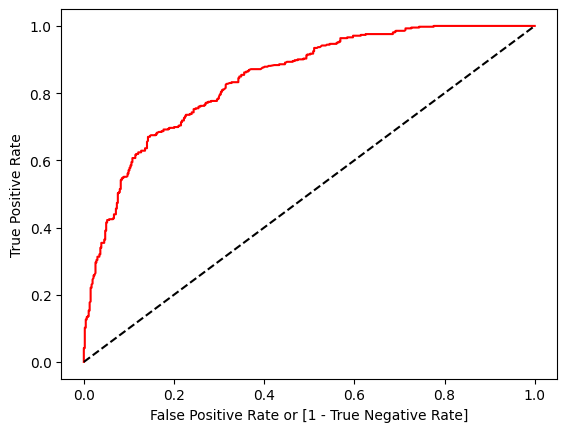

In [21]:
fpr, tpr, thresholds = roc_curve(y_train, rf_classifier.predict_proba (X_train)[:,1])

auc = roc_auc_score(y_train,y_pred_train)
print(auc)

import matplotlib.pyplot as plt
plt.plot(fpr, tpr, color='red', label='logit model ( area  = %0.2f)'%auc)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate or [1 - True Negative Rate]')
plt.ylabel('True Positive Rate')

### 8.2 Testing Data's Evaluation Metrics

In [22]:
print(confusion_matrix(y_test,y_pred_test))

[[79 35]
 [32 74]]


In [23]:
print(classification_report(y_test,y_pred_test))

              precision    recall  f1-score   support

           0       0.71      0.69      0.70       114
           1       0.68      0.70      0.69       106

    accuracy                           0.70       220
   macro avg       0.70      0.70      0.70       220
weighted avg       0.70      0.70      0.70       220



0.6955478318437603


Text(0, 0.5, 'True Positive Rate')

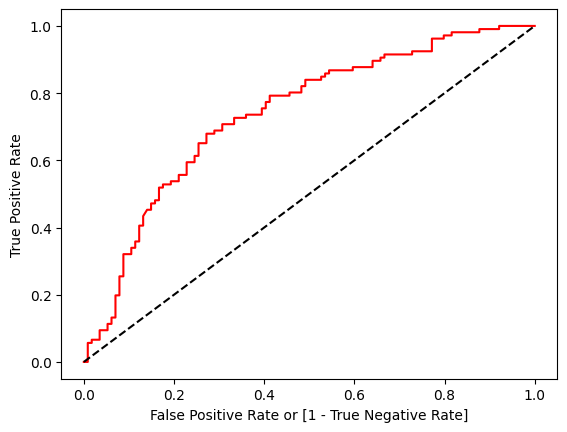

In [24]:
fpr, tpr, thresholds = roc_curve(y_test, rf_classifier.predict_proba (X_test)[:,1])

auc = roc_auc_score(y_test,y_pred_test)
print(auc)

import matplotlib.pyplot as plt
plt.plot(fpr, tpr, color='red', label='logit model ( area  = %0.2f)'%auc)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate or [1 - True Negative Rate]')
plt.ylabel('True Positive Rate')

## 9. Model Deployment

In [25]:
from pickle import dump

## BIAS - VARIANCE

* Training Error/Accuracy - Bias
* Test Error/Accuracy - Variance.

### Model Overfitting - Less Bias and High Variance.
### Model Underfitting - High Bias and Less Variance.

### EXPECTED MODEL -- GENERALIZED MODEL - Less Bias and Less Variance.

So, there is always a **Tradeoff maintaned between Bias and Variance.**

### The End!!!